In [ ]:
from google.colab import files

# Upload the file from your local system
# This will open a file selection dialog
uploaded = files.upload()

Saving kc_house_data.csv to kc_house_data.csv


In [ ]:
# ============================================================
# STEP 1: Import Required Libraries
# ============================================================

import pandas as pd          # For loading and working with data
import numpy as np           # For numerical calculations
import matplotlib.pyplot as plt  # For creating graphs and charts

# Sklearn - for Machine Learning algorithms
from sklearn.linear_model import LinearRegression    # Linear Regression model
from sklearn.cluster import KMeans                   # K-Means Clustering model
from sklearn.model_selection import train_test_split # Split data into train/test
from sklearn.metrics import r2_score                 # To check model accuracy

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# ============================================================
# STEP 2: Load the Dataset
# ============================================================

# Load CSV file into a DataFrame (like a table)
df = pd.read_csv('kc_house_data.csv')

# Show the first 5 rows of the dataset
print("First 5 rows of the dataset:")
print(df.head())

print("\n" + "="*50)

# Show the shape: (rows, columns)
print(f"\nDataset Size: {df.shape[0]} rows and {df.shape[1]} columns")

print("\nColumn Names:")
print(df.columns.tolist())

First 5 rows of the dataset:
           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renov

In [ ]:
# ============================================================
# STEP 3: Basic Dataset Information
# ============================================================

# Show data types and count of non-null values
print("Dataset Information:")
print(df.info())

print("\nBasic Statistics:")
print(df[['price', 'sqft_living', 'bedrooms', 'bathrooms', 'floors']].describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null

In [ ]:
# ============================================================
# STEP 4: Data Preprocessing
# ============================================================

# --- 4a. Select Only Useful Columns ---
# Features we will use to predict the price
feature_columns = ['sqft_living', 'bedrooms', 'bathrooms', 'floors']

# The value we want to predict
target_column = 'price'

# Create a new small dataframe with only the columns we need
selected_data = df[feature_columns + [target_column]]

print("Selected Columns:")
print(selected_data.head())

print("\n" + "="*50)

# --- 4b. Check for Missing Values ---
print("\nMissing Values in Each Column:")
print(selected_data.isnull().sum())

# Drop rows with missing values (if any)
selected_data = selected_data.dropna()
print(f"\nRows after removing missing values: {len(selected_data)}")

print("\n Data preprocessing complete!")

Selected Columns:
   sqft_living  bedrooms  bathrooms  floors     price
0         1180         3       1.00     1.0  221900.0
1         2570         3       2.25     2.0  538000.0
2          770         2       1.00     1.0  180000.0
3         1960         4       3.00     1.0  604000.0
4         1680         3       2.00     1.0  510000.0


Missing Values in Each Column:
sqft_living    0
bedrooms       0
bathrooms      0
floors         0
price          0
dtype: int64

Rows after removing missing values: 21613

 Data preprocessing complete!


In [ ]:
# ============================================================
# STEP 5: Separate Features (X) and Target (y)
# ============================================================

# X = Features (inputs) — what we give to the model
X = selected_data[feature_columns]

# y = Target (output) — what we want to predict
y = selected_data[target_column]

print("Features (X) - first 5 rows:")
print(X.head())

print("\nTarget (y) - first 5 values:")
print(y.head())

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

Features (X) - first 5 rows:
   sqft_living  bedrooms  bathrooms  floors
0         1180         3       1.00     1.0
1         2570         3       2.25     2.0
2          770         2       1.00     1.0
3         1960         4       3.00     1.0
4         1680         3       2.00     1.0

Target (y) - first 5 values:
0    221900.0
1    538000.0
2    180000.0
3    604000.0
4    510000.0
Name: price, dtype: float64

X shape: (21613, 4)
y shape: (21613,)


In [ ]:
# ============================================================
# STEP 6: Split Data into Training and Testing Sets
# ============================================================

# Split: 80% for training, 20% for testing
# random_state=42 ensures we get the same split every time we run
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42      # Fixed seed for reproducibility
)

print("Data Split Results:")
print(f"  Total samples    : {len(X)}")
print(f"  Training samples : {len(X_train)} (80%)")
print(f"  Testing samples  : {len(X_test)} (20%)")

Data Split Results:
  Total samples    : 21613
  Training samples : 17290 (80%)
  Testing samples  : 4323 (20%)


In [ ]:
# ============================================================
# STEP 7: Train the Linear Regression Model
# ============================================================

# Create the Linear Regression model object
lr_model = LinearRegression()

# Train (fit) the model using training data
# The model learns the relationship between features and price
lr_model.fit(X_train, y_train)

print(" Model trained successfully!")

# Show the learned coefficients (weights for each feature)
print("\nModel Coefficients (weights learned by model):")
for feature, coef in zip(feature_columns, lr_model.coef_):
    print(f"  {feature:15s}: {coef:,.2f}")

print(f"\nBias (Intercept): {lr_model.intercept_:,.2f}")

 Model trained successfully!

Model Coefficients (weights learned by model):
  sqft_living    : 305.63
  bedrooms       : -56,445.97
  bathrooms      : 11,748.92
  floors         : -1,103.49

Bias (Intercept): 70,857.03


In [ ]:
# ============================================================
# STEP 8: Predict House Prices
# ============================================================

# Use the trained model to predict prices on test data
y_predicted = lr_model.predict(X_test)

# Compare actual vs predicted prices (first 10 results)
print("Comparison: Actual Price vs Predicted Price")
print("-" * 45)
print(f"{'#':<5} {'Actual Price':>15} {'Predicted Price':>15}")
print("-" * 45)

for i in range(10):
    actual = y_test.iloc[i]
    predicted = y_predicted[i]
    print(f"{i+1:<5} ${actual:>14,.0f} ${predicted:>14,.0f}")

print("-" * 45)

Comparison: Actual Price vs Predicted Price
---------------------------------------------
#        Actual Price Predicted Price
---------------------------------------------
1     $       365,000 $       501,959
2     $       865,000 $       709,102
3     $     1,038,000 $     1,024,470
4     $     1,490,000 $     1,334,114
5     $       711,000 $       708,045
6     $       211,000 $       389,546
7     $       790,000 $       694,388
8     $       680,000 $       479,925
9     $       384,500 $       417,695
10    $       605,000 $       246,735
---------------------------------------------


In [ ]:
# ============================================================
# STEP 9: Check Model Accuracy using R² Score
# ============================================================

# R² (R-squared) Score:
# - Value between 0 and 1
# - Closer to 1 means better accuracy
# - Example: 0.65 means model explains 65% of price variation

r2 = r2_score(y_test, y_predicted)

print("Model Accuracy Results:")
print(f"  R² Score: {r2:.4f}")
print(f"  Accuracy: {r2 * 100:.2f}%")

# Interpretation
if r2 >= 0.70:
    print("  Result  :  Good Model Accuracy!")
elif r2 >= 0.50:
    print("  Result  :   Moderate Accuracy")
else:
    print("  Result  :  Low Accuracy - needs improvement")

print("\nInterpretation:")
print(f"  The model can explain {r2*100:.1f}% of the variation in house prices.")

Model Accuracy Results:
  R² Score: 0.5089
  Accuracy: 50.89%
  Result  :   Moderate Accuracy

Interpretation:
  The model can explain 50.9% of the variation in house prices.


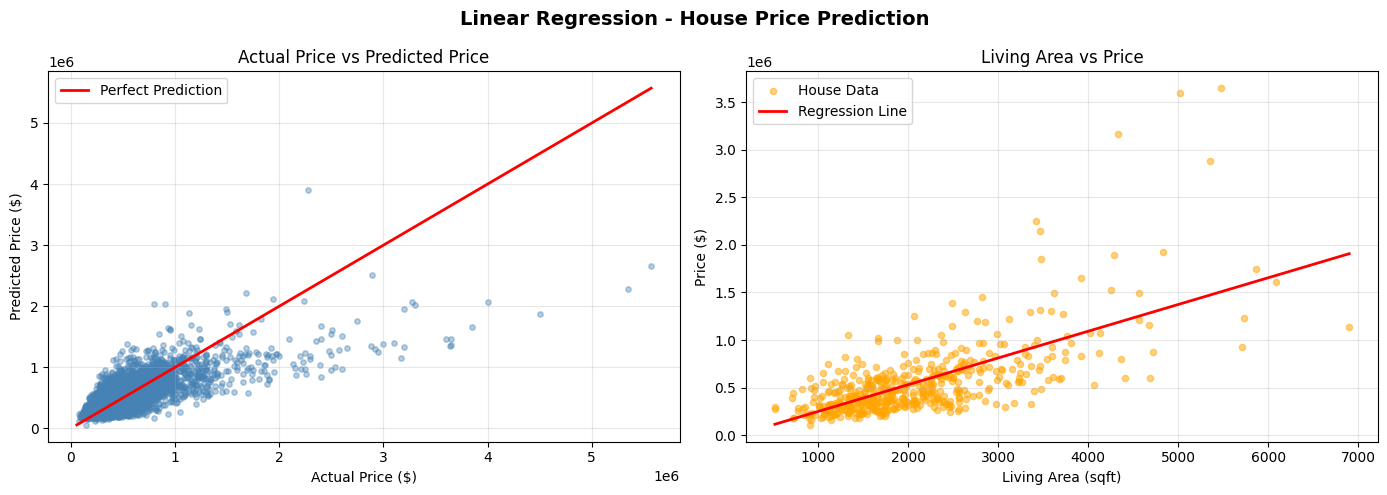

 Regression plots displayed!


In [ ]:
# ============================================================
# STEP 10: Regression Visualization
# ============================================================

# Create a figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Linear Regression - House Price Prediction', fontsize=14, fontweight='bold')

# ----- Plot 1: Actual vs Predicted Prices -----
axes[0].scatter(y_test, y_predicted, color='steelblue', alpha=0.4, s=15)

# Draw a perfect prediction line (diagonal)
min_val = min(y_test.min(), y_predicted.min())
max_val = max(y_test.max(), y_predicted.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2, label='Perfect Prediction')

axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Actual Price vs Predicted Price')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ----- Plot 2: sqft_living vs Price with Regression Line -----
# Sample 500 points for cleaner plot
sample = selected_data.sample(500, random_state=42)

axes[1].scatter(sample['sqft_living'], sample['price'],
                color='orange', alpha=0.5, s=20, label='House Data')
# Draw a simple regression line for sqft_living vs price
sqft_values = np.linspace(sample['sqft_living'].min(), sample['sqft_living'].max(), 100)

# Simple linear fit for visualization
poly = np.polyfit(sample['sqft_living'], sample['price'], 1)
price_line = np.polyval(poly, sqft_values)

axes[1].plot(sqft_values, price_line, color='red', linewidth=2, label='Regression Line')
axes[1].set_xlabel('Living Area (sqft)')
axes[1].set_ylabel('Price ($)')
axes[1].set_title('Living Area vs Price')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" Regression plots displayed!")


In [ ]:
# ============================================================
# STEP 11: Prepare Data for K-Means Clustering
# ============================================================

# Select features for clustering
cluster_features = ['price', 'sqft_living']

# Create a new dataframe with only clustering features
cluster_data = df[cluster_features].dropna()

print("Clustering Data - first 5 rows:")
print(cluster_data.head())

print(f"\nTotal rows for clustering: {len(cluster_data)}")
print(f"Price range: ${cluster_data['price'].min():,.0f} — ${cluster_data['price'].max():,.0f}")
print(f"Sqft range : {cluster_data['sqft_living'].min()} — {cluster_data['sqft_living'].max()} sqft")

Clustering Data - first 5 rows:
      price  sqft_living
0  221900.0         1180
1  538000.0         2570
2  180000.0          770
3  604000.0         1960
4  510000.0         1680

Total rows for clustering: 21613
Price range: $75,000 — $7,700,000
Sqft range : 290 — 13540 sqft


In [ ]:
# ============================================================
# STEP 12: Apply K-Means Clustering
# ============================================================

# Create K-Means model with 3 clusters
kmeans_model = KMeans(
    n_clusters=3,      # We want 3 groups
    random_state=42,   # Fixed seed so results are same every time
    n_init=10          # Run 10 times, pick the best result
)

# Fit the model — it finds the 3 groups automatically
kmeans_model.fit(cluster_data)

# Get cluster label for each house (0, 1, or 2)
cluster_labels = kmeans_model.labels_

# Add cluster labels back to the data
cluster_data = cluster_data.copy()
cluster_data['Cluster'] = cluster_labels

print(" K-Means Clustering complete!")
print("\nCluster Labels (first 15 values):")
print(cluster_labels[:15])

print("\nNumber of houses in each cluster:")
print(cluster_data['Cluster'].value_counts().sort_index())

 K-Means Clustering complete!

Cluster Labels (first 15 values):
[1 1 1 0 1 0 1 1 1 1 0 1 1 1 1]

Number of houses in each cluster:
Cluster
0     5915
1    15094
2      604
Name: count, dtype: int64


In [ ]:
# ============================================================
# STEP 13: Identify and Label Clusters (Budget / Medium / Luxury)
# ============================================================

# Get the centroid (center point) of each cluster
centroids = kmeans_model.cluster_centers_

print("Cluster Centroids (Center Points):")
print("-" * 45)
print(f"{'Cluster':<10} {'Avg Price':>15} {'Avg Sqft':>12}")
print("-" * 45)
for i, centroid in enumerate(centroids):
    print(f"Cluster {i}  ${centroid[0]:>14,.0f} {centroid[1]:>11.0f}")
print("-" * 45)

# -----------------------------------------------------------
# Automatically assign names based on average price
# Cluster with highest avg price = Luxury
# Cluster with lowest avg price  = Budget
# Middle one                     = Medium
# -----------------------------------------------------------

# Get average price for each cluster (index 0 = price column)
avg_prices = {i: centroids[i][0] for i in range(3)}

# Sort clusters by average price
sorted_clusters = sorted(avg_prices, key=avg_prices.get)

# Assign names
cluster_names = {}
cluster_names[sorted_clusters[0]] = 'Budget Houses'
cluster_names[sorted_clusters[1]] = 'Medium Houses'
cluster_names[sorted_clusters[2]] = 'Luxury Houses'

# Add house category name to data
cluster_data['Category'] = cluster_data['Cluster'].map(cluster_names)

print("\nCluster Name Assignments:")
for cluster_id, name in cluster_names.items():
    avg_p = avg_prices[cluster_id]
    print(f"  Cluster {cluster_id} → {name:<20} (Avg Price: ${avg_p:,.0f})")

print("\nSample of clustered data:")
print(cluster_data.head(10))

Cluster Centroids (Center Points):
---------------------------------------------
Cluster          Avg Price     Avg Sqft
---------------------------------------------
Cluster 0  $       809,376        2723
Cluster 1  $       374,942        1738
Cluster 2  $     2,030,683        4333
---------------------------------------------

Cluster Name Assignments:
  Cluster 1 → Budget Houses        (Avg Price: $374,942)
  Cluster 0 → Medium Houses        (Avg Price: $809,376)
  Cluster 2 → Luxury Houses        (Avg Price: $2,030,683)

Sample of clustered data:
       price  sqft_living  Cluster       Category
0   221900.0         1180        1  Budget Houses
1   538000.0         2570        1  Budget Houses
2   180000.0          770        1  Budget Houses
3   604000.0         1960        0  Medium Houses
4   510000.0         1680        1  Budget Houses
5  1225000.0         5420        0  Medium Houses
6   257500.0         1715        1  Budget Houses
7   291850.0         1060        1  Budget 

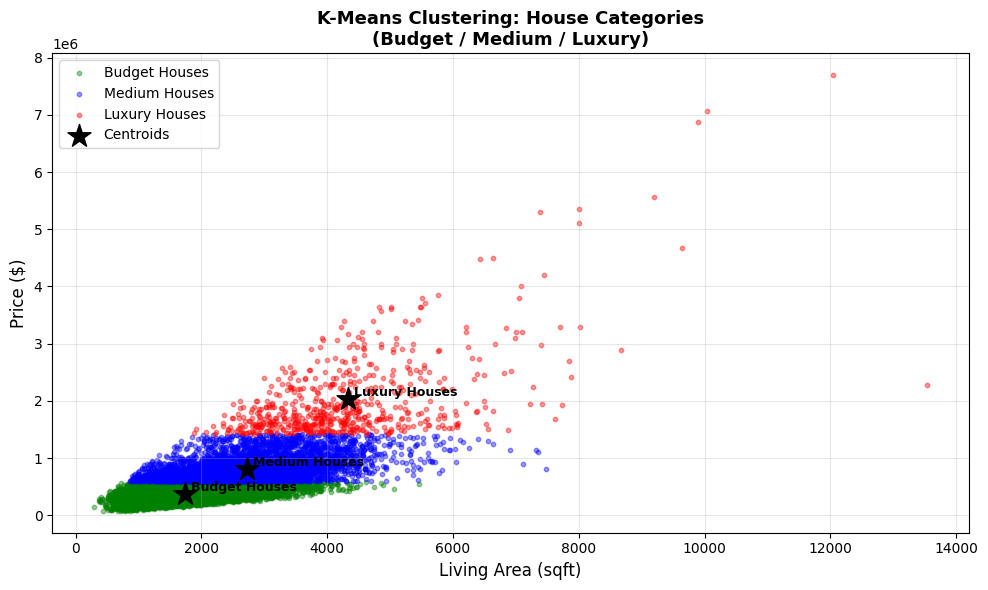

 Clustering visualization displayed!


In [ ]:
# ============================================================
# STEP 14: Clustering Visualization
# ============================================================

# Define colors for each category
color_map = {
    'Budget Houses' : 'green',
    'Medium Houses' : 'blue',
    'Luxury Houses' : 'red'
}

# Create figure
plt.figure(figsize=(10, 6))

# Plot each cluster with its own color
for category, color in color_map.items():
    # Get rows belonging to this category
    group = cluster_data[cluster_data['Category'] == category]
    plt.scatter(
        group['sqft_living'],  # X axis = Living Area
        group['price'],        # Y axis = Price
        c=color,
        label=category,
        alpha=0.4,
        s=10
    )

# Plot the centroids as big star markers
plt.scatter(
    centroids[:, 1],   # sqft_living of centroids
    centroids[:, 0],   # price of centroids
    c='black',
    marker='*',        # Star shape
    s=300,
    zorder=5,          # Draw on top
    label='Centroids'
)

# Add centroid labels
for i, centroid in enumerate(centroids):
    name = cluster_names[i]
    plt.annotate(
        name,
        xy=(centroid[1], centroid[0]),
        xytext=(centroid[1] + 100, centroid[0] + 50000),
        fontsize=9,
        color='black',
        fontweight='bold'
    )

# Labels and title
plt.xlabel('Living Area (sqft)', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.title('K-Means Clustering: House Categories\n(Budget / Medium / Luxury)', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(" Clustering visualization displayed!")

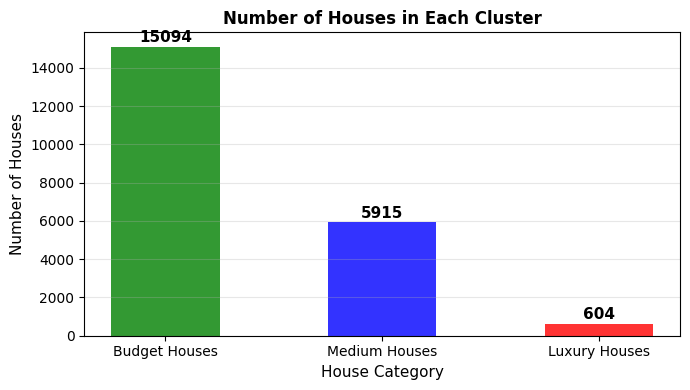

House Count per Cluster:
  Budget Houses       : 15094 houses
  Medium Houses       : 5915 houses
  Luxury Houses       : 604 houses


In [ ]:
# ============================================================
# STEP 15: Cluster Summary (Bar Chart)
# ============================================================

# Count how many houses are in each category
category_counts = cluster_data['Category'].value_counts()

# Define order for display
order = ['Budget Houses', 'Medium Houses', 'Luxury Houses']
counts = [category_counts.get(cat, 0) for cat in order]
colors = ['green', 'blue', 'red']

# Create bar chart
plt.figure(figsize=(7, 4))
bars = plt.bar(order, counts, color=colors, width=0.5, alpha=0.8)

# Add count labels on top of each bar
for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        str(count),
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.xlabel('House Category', fontsize=11)
plt.ylabel('Number of Houses', fontsize=11)
plt.title('Number of Houses in Each Cluster', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("House Count per Cluster:")
for cat, count in zip(order, counts):
    print(f"  {cat:<20}: {count} houses")

In [ ]:
# ============================================================
# STEP 16: Final Interpretation Summary
# ============================================================

print("=" * 60)
print("       FINAL RESULTS SUMMARY")
print("=" * 60)

print("\n LINEAR REGRESSION RESULTS")
print("-" * 40)
print(f"  R² Score  : {r2:.4f}  ({r2*100:.1f}% accuracy)")
print("  Meaning   : The model learned that bigger houses")
print("              (more sqft) have higher prices.")
print("  Top Feature: sqft_living has the most impact on price.")

print("\n K-MEANS CLUSTERING RESULTS")
print("-" * 40)
print("  3 clusters were created automatically:")

for cat in ['Budget Houses', 'Medium Houses', 'Luxury Houses']:
    group = cluster_data[cluster_data['Category'] == cat]
    avg_p = group['price'].mean()
    avg_s = group['sqft_living'].mean()
    count = len(group)
    print(f"\n   {cat}")
    print(f"     Houses   : {count}")
    print(f"     Avg Price: ${avg_p:,.0f}")
    print(f"     Avg Size : {avg_s:.0f} sqft")

print("\n" + "=" * 60)
print("  Both algorithms worked correctly on real house data!")
print("=" * 60)

       FINAL RESULTS SUMMARY

 LINEAR REGRESSION RESULTS
----------------------------------------
  R² Score  : 0.5089  (50.9% accuracy)
  Meaning   : The model learned that bigger houses
              (more sqft) have higher prices.
  Top Feature: sqft_living has the most impact on price.

 K-MEANS CLUSTERING RESULTS
----------------------------------------
  3 clusters were created automatically:

   Budget Houses
     Houses   : 15094
     Avg Price: $374,927
     Avg Size : 1738 sqft

   Medium Houses
     Houses   : 5915
     Avg Price: $809,339
     Avg Size : 2723 sqft

   Luxury Houses
     Houses   : 604
     Avg Price: $2,030,683
     Avg Size : 4333 sqft

  Both algorithms worked correctly on real house data!


In [ ]:
# ============================================================
# BONUS: Predict Price for a Custom House
# ============================================================

# Enter your own house details below and see the predicted price!

my_house_sqft      = 2000   # Living area in square feet
my_house_bedrooms  = 3      # Number of bedrooms
my_house_bathrooms = 2      # Number of bathrooms
my_house_floors    = 1      # Number of floors

# Put these values in the same format as training data
my_house = pd.DataFrame({
    'sqft_living': [my_house_sqft],
    'bedrooms'   : [my_house_bedrooms],
    'bathrooms'  : [my_house_bathrooms],
    'floors'     : [my_house_floors]
})

# Predict price
my_predicted_price = lr_model.predict(my_house)[0]

print(" My Custom House:")
print(f"   Living Area : {my_house_sqft} sqft")
print(f"   Bedrooms    : {my_house_bedrooms}")
print(f"   Bathrooms   : {my_house_bathrooms}")
print(f"   Floors      : {my_house_floors}")
print(f"\n Predicted Price: ${my_predicted_price:,.0f}")

# KMeans was trained on [price, sqft_living], so use those same features
my_house_cluster_input = pd.DataFrame({
    'price'      : [my_predicted_price],   # use predicted price
    'sqft_living': [my_house_sqft]
})

my_cluster_id   = kmeans_model.predict(my_house_cluster_input)[0]
my_cluster_name = cluster_names[my_cluster_id]

print(f"\n Cluster Assignment: Cluster {my_cluster_id} → {my_cluster_name}")
print(f"   This house falls in the '{my_cluster_name}' category")

 My Custom House:
   Living Area : 2000 sqft
   Bedrooms    : 3
   Bathrooms   : 2
   Floors      : 1

 Predicted Price: $535,177
